a) 

Objetivo alcanzado. Tiempo final = 63.26 s


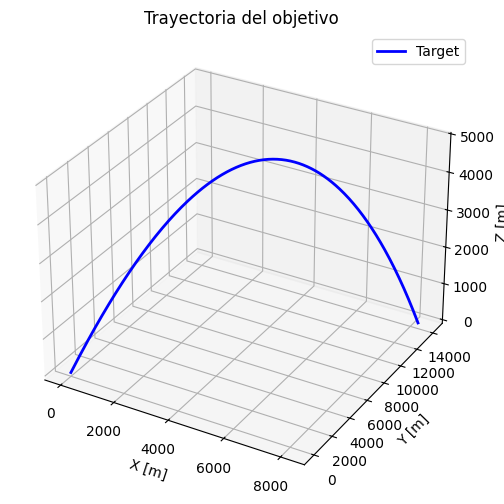

Mejor distancia = 160.70 m con los parámetros: v_2=1000, theta=80.0 y psi=330.0
Parámetros refinados: v_2=719.0, theta=51.4, psi=328.2 y distancia=0.0012 m

Victoria alcanzada: Existe una colisión posible con una distancia = 0.001 m <= 10.0 m

Tiempo de encuentro desde el primer lanzamiento: 19.20 s
Tiempo de intercepción: 9.20 s


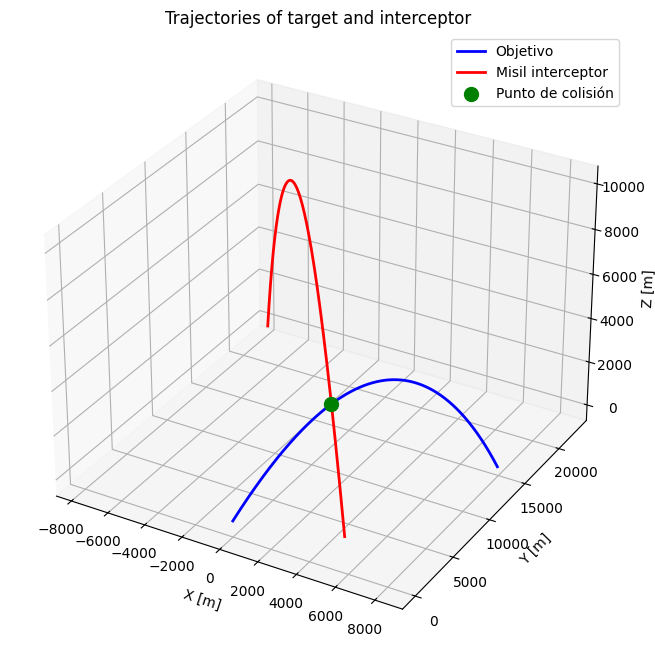

C:\Users\msilv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


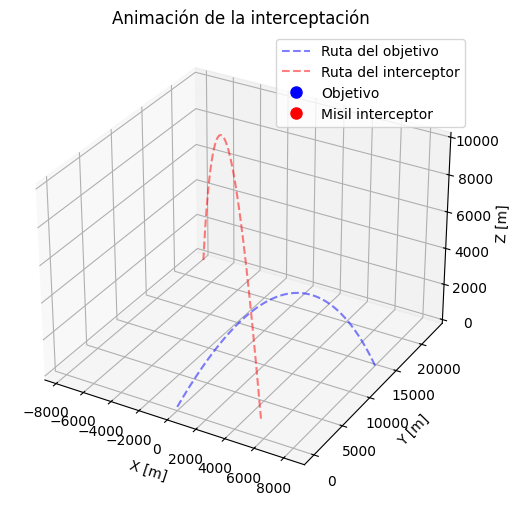


Resumen de los mejores parámetros encontrados:
Velocidad inicial v2_0 = 719.0 m/s
Ángulo de elevación θ2 = 51.42°
Ángulo azimutal ψ2 = 328.16°
Separación mínima = 0.001 m
Tiempo de encuentro desde el lanzamiento del objetivo = 19.20 s
Tiempo de vuelo del misil interceptor = 9.20 s


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize, differential_evolution
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import time

# ====================================================
# (a) Modelo Matemático
# ====================================================

g = 9.81                     # gravity [m/s^2]
rho = 1.225                  # air density at sea level [kg/m^3]
Cd = 0.5                     # drag coefficient (dimensionless)
A = 0.1                      # cross-sectional area [m^2]
mass = 1000.0                # mass of each missile [kg] (assumed same)

# Earth rotation (angular velocity vector) – assume latitude 45° N
Omega = 7.292115e-5          # Earth rotation rate [rad/s]
lat = np.radians(45.0)       # latitude
omega_vec = np.array([0.0, Omega * np.cos(lat), Omega * np.sin(lat)])
# In local coordinates: x = east, y = north, z = up

# Drag coefficient combined
k_drag = 0.5 * rho * Cd * A / mass

# State vector: [x, y, z, vx, vy, vz]
def equations_of_motion(t, state, omega):
    x, y, z, vx, vy, vz = state
    v = np.array([vx, vy, vz])
    v_mag = np.linalg.norm(v)
    
    # Gravity (downward)
    a_grav = np.array([0.0, 0.0, -g])
    
    # Quadratic drag (opposite to velocity)
    a_drag = -k_drag * v_mag * v
    
    # Coriolis acceleration: -2 * omega × v
    a_cor = -2.0 * np.cross(omega, v)
    
    # Centrifugal acceleration: -omega × (omega × r)
    r_vec = np.array([x, y, z])
    a_cf = -np.cross(omega, np.cross(omega, r_vec))
    
    # Total acceleration
    a_total = a_grav + a_drag + a_cor + a_cf
    
    return [vx, vy, vz, a_total[0], a_total[1], a_total[2]]

def angle_to_velocity_vector(v0, theta_deg, psi_deg):
    """Convert speed and angles to velocity vector (x east, y north, z up)."""
    theta = np.radians(theta_deg)
    psi = np.radians(psi_deg)
    vx = v0 * np.cos(theta) * np.sin(psi)   # east component
    vy = v0 * np.cos(theta) * np.cos(psi)   # north component
    vz = v0 * np.sin(theta)                 # vertical component
    return np.array([vx, vy, vz])

def simulate_trajectory(r0, v0_vec, t_span, t_eval=None, omega=omega_vec):
    """Simulate projectile motion using solve_ivp."""
    state0 = [r0[0], r0[1], r0[2], v0_vec[0], v0_vec[1], v0_vec[2]]
    def rhs(t, state):
        return equations_of_motion(t, state, omega)
    # Stop when z < 0 (ground impact) or time limit reached
    def ground_event(t, state):
        return state[2]   # z coordinate
    ground_event.terminal = True
    ground_event.direction = -1
    sol = solve_ivp(rhs, t_span, state0, t_eval=t_eval, events=ground_event,
                    method='RK45', rtol=1e-8, atol=1e-8)
    return sol.t, sol.y.T   # times and array of states

# ====================================================
# (b) Simulación del cuerpo
# ====================================================
# Target initial conditions
r1_0 = np.array([0.0, 0.0, 0.0])
v1_0 = 500.0          # m/s
theta1 = 45.0         # deg
psi1 = 30.0           # deg
v1_vec = angle_to_velocity_vector(v1_0, theta1, psi1)

# Time span for target (up to 100 seconds, or until ground impact)
t_span_target = (0, 200)
t_eval_target = np.linspace(0, 200, 1000)
t_target, traj_target = simulate_trajectory(r1_0, v1_vec, t_span_target, t_eval_target)

print("Objetivo alcanzado. Tiempo final = {:.2f} s".format(t_target[-1]))

# 3D plot of target trajectory
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(traj_target[:,0], traj_target[:,1], traj_target[:,2], 'b-', linewidth=2, label='Target')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')
ax.set_title('Trayectoria del objetivo')
ax.legend()
plt.show()

# ====================================================
# (c) Determinación de los parámetros
# ====================================================
tau = 10.0                # delay [s]
r2_0 = np.array([5000.0, 2000.0, 0.0])
dtol = 10.0               # collision tolerance [m]

# Precompute target trajectory as a function of time for quick interpolation
# We'll use linear interpolation to get target position at arbitrary times
from scipy.interpolate import interp1d
target_x = interp1d(t_target, traj_target[:,0], kind='linear', fill_value='extrapolate')
target_y = interp1d(t_target, traj_target[:,1], kind='linear', fill_value='extrapolate')
target_z = interp1d(t_target, traj_target[:,2], kind='linear', fill_value='extrapolate')

def get_target_position(t):
    return np.array([target_x(t), target_y(t), target_z(t)])

def interceptor_min_distance(params):
    """Compute minimum distance between interceptor and target for given parameters.
       params = [v2, theta2_deg, psi2_deg]"""
    v2, theta2, psi2 = params
    # Constraints
    if v2 < 300 or v2 > 1000 or theta2 < 10 or theta2 > 80:
        return 1e9   # penalty
    v2_vec = angle_to_velocity_vector(v2, theta2, psi2)
    # Simulate interceptor from t=tau onward
    t_span_int = (tau, tau + 100)   # max 100 s flight
    t_eval_int = np.linspace(tau, tau + 100, 500)
    t_int, traj_int = simulate_trajectory(r2_0, v2_vec, t_span_int, t_eval_int)
    if len(t_int) == 0:
        return 1e9
    # Compute distances to target at corresponding times
    min_dist = 1e9
    for t, state in zip(t_int, traj_int):
        pos_target = get_target_position(t)
        dist = np.linalg.norm(state[:3] - pos_target)
        if dist < min_dist:
            min_dist = dist
    return min_dist

# Grid search (coarse) to get initial guess
v2_range = np.linspace(300, 1000, 8)
theta2_range = np.linspace(10, 80, 8)
psi2_range = np.linspace(0, 360, 12, endpoint=False)
best_dist = 1e9
best_params = None
for v2 in v2_range:
    for theta2 in theta2_range:
        for psi2 in psi2_range:
            dist = interceptor_min_distance([v2, theta2, psi2])
            if dist < best_dist:
                best_dist = dist
                best_params = [v2, theta2, psi2]
print(f"Mejor distancia = {best_dist:.2f} m con los parámetros: v_2={v2:.0f}, theta={theta2:.1f} y psi={psi2:.1f}")

# Refine with local optimization using Nelder-Mead
if best_dist < 1000:
    result = minimize(interceptor_min_distance, best_params, method='Nelder-Mead',
                      bounds=[(300,1000),(10,80),(0,360)], tol=1e-3)
    best_params = result.x
    best_dist = result.fun
    print(f"Parámetros refinados: v_2={best_params[0]:.1f}, theta={best_params[1]:.1f}, psi={best_params[2]:.1f} y distancia={best_dist:.4f} m")
else:
    print("No se puedo encontrar una mejor opción de parámetros.")

# Final check
if best_dist <= dtol:
    print("\nVictoria alcanzada: Existe una colisión posible con una distancia = {:.3f} m <= {:.1f} m".format(best_dist, dtol))
else:
    print("\nAdvertencia: Algo salió mal. Mínima distancia = {:.3f} m > tolerancia {:.1f} m. No hay colisión exacta.".format(best_dist, dtol))

# ====================================================
# (d) Tiempo de encuentro de ambos misiles
# ====================================================
# Simulate both trajectories with best parameters to find encounter time
v2_best, theta2_best, psi2_best = best_params
v2_vec_best = angle_to_velocity_vector(v2_best, theta2_best, psi2_best)
t_span_int = (tau, tau + 100)
t_eval_int = np.linspace(tau, tau + 100, 2000)
t_int, traj_int = simulate_trajectory(r2_0, v2_vec_best, t_span_int, t_eval_int)

encounter_time = None
min_dist_time = None
min_dist_val = 1e9
for t, state in zip(t_int, traj_int):
    pos_target = get_target_position(t)
    dist = np.linalg.norm(state[:3] - pos_target)
    if dist < min_dist_val:
        min_dist_val = dist
        min_dist_time = t
if min_dist_val <= dtol:
    encounter_time = min_dist_time
    interceptor_flight_time = encounter_time - tau
    print(f"\nTiempo de encuentro desde el primer lanzamiento: {encounter_time:.2f} s")
    print(f"Tiempo de intercepción: {interceptor_flight_time:.2f} s")
else:
    print(f"\nAproximación más cercana en t = {min_dist_time:.2f} s con distancia {min_dist_val:.2f} m")

# ====================================================
# (e) Simulación en 3D de ambas trayectorias 
# ====================================================
# Re-simulate target with fine time resolution for plotting
t_target_fine = np.linspace(0, t_target[-1], 500)
_, traj_target_fine = simulate_trajectory(r1_0, v1_vec, (0, t_target[-1]), t_target_fine)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(traj_target_fine[:,0], traj_target_fine[:,1], traj_target_fine[:,2], 'b-', linewidth=2, label='Objetivo')
ax.plot(traj_int[:,0], traj_int[:,1], traj_int[:,2], 'r-', linewidth=2, label='Misil interceptor')
if best_dist <= dtol and encounter_time is not None:
    # Mark collision point
    pos_coll = get_target_position(encounter_time)
    ax.scatter(*pos_coll, color='green', s=100, marker='o', label='Punto de colisión')
else:
    # Mark point of closest approach
    pos_closest = get_target_position(min_dist_time)
    ax.scatter(*pos_closest, color='orange', s=100, marker='x', label='Aproximación más cercana')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')
ax.set_title('Trajectories of target and interceptor')
ax.legend()
plt.show()

# ====================================================
# (f) Animación de la colisión
# ====================================================
# Create a common time grid from 0 to max(t_target[-1], t_int[-1])
t_max = max(t_target[-1], t_int[-1])
t_anim = np.linspace(0, t_max, 300)

# Interpolate target and interceptor positions
target_x_interp = interp1d(t_target, traj_target[:,0], kind='linear', fill_value='extrapolate')
target_y_interp = interp1d(t_target, traj_target[:,1], kind='linear', fill_value='extrapolate')
target_z_interp = interp1d(t_target, traj_target[:,2], kind='linear', fill_value='extrapolate')
int_x_interp = interp1d(t_int, traj_int[:,0], kind='linear', fill_value='extrapolate')
int_y_interp = interp1d(t_int, traj_int[:,1], kind='linear', fill_value='extrapolate')
int_z_interp = interp1d(t_int, traj_int[:,2], kind='linear', fill_value='extrapolate')

fig_anim = plt.figure(figsize=(10, 6))
ax_anim = fig_anim.add_subplot(111, projection='3d')
ax_anim.plot(traj_target_fine[:,0], traj_target_fine[:,1], traj_target_fine[:,2], 'b--', alpha=0.5, label='Ruta del objetivo')
ax_anim.plot(traj_int[:,0], traj_int[:,1], traj_int[:,2], 'r--', alpha=0.5, label='Ruta del interceptor')
target_point, = ax_anim.plot([], [], [], 'bo', markersize=8, label='Objetivo')
interceptor_point, = ax_anim.plot([], [], [], 'ro', markersize=8, label='Misil interceptor')
ax_anim.set_xlabel('X [m]')
ax_anim.set_ylabel('Y [m]')
ax_anim.set_zlabel('Z [m]')
ax_anim.set_title('Animación de la interceptación')
ax_anim.legend()

def animate(i):
    t = t_anim[i]
    if t <= t_target[-1]:
        tx = target_x_interp(t)
        ty = target_y_interp(t)
        tz = target_z_interp(t)
        target_point.set_data([tx], [ty])
        target_point.set_3d_properties([tz])
    if t >= tau and t <= t_int[-1]:
        ix = int_x_interp(t)
        iy = int_y_interp(t)
        iz = int_z_interp(t)
        interceptor_point.set_data([ix], [iy])
        interceptor_point.set_3d_properties([iz])
    return target_point, interceptor_point

anim = animation.FuncAnimation(fig_anim, animate, frames=len(t_anim), interval=50, blit=False)
plt.show()


# Summary output
print("\n" + "="*50)
print("Resumen de los mejores parámetros encontrados:")
print("="*50)
print(f"Velocidad inicial v2_0 = {best_params[0]:.1f} m/s")
print(f"Ángulo de elevación θ2 = {best_params[1]:.2f}°")
print(f"Ángulo azimutal ψ2 = {best_params[2]:.2f}°")
print(f"Separación mínima = {best_dist:.3f} m")
if encounter_time is not None:
    print(f"Tiempo de encuentro desde el lanzamiento del objetivo = {encounter_time:.2f} s")
    print(f"Tiempo de vuelo del misil interceptor = {encounter_time - tau:.2f} s")
else:
    print(f"Tiempo de aproximación más cercana = {min_dist_time:.2f} s")